# Нейронный машинный перевод English → German
## LSTM Encoder-Decoder vs Bahdanau Attention

**Цель:** реализовать и сравнить две архитектуры нейронного машинного перевода:
1. Базовая модель Encoder-Decoder на основе LSTM (без механизма внимания)
2. Улучшенная модель Encoder-Decoder с аддитивным вниманием (Bahdanau Attention)

**Набор данных:** English-German sentence pairs из [Tatoeba Project](https://www.kaggle.com/datasets/kaushal2896/english-to-german) (~240 000 пар предложений)

In [1]:
!pip install -q nltk

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import re, random, math, time, os, warnings
from collections import Counter

import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Устройство: {device}')

Устройство: cuda


## 1. Загрузка и подготовка данных

In [2]:
# Загрузка датасета English-German из Tatoeba Project
# Источник: https://www.kaggle.com/datasets/kaushal2896/english-to-german
!wget -q http://www.manythings.org/anki/deu-eng.zip -O deu-eng.zip
!unzip -oq deu-eng.zip
print('Файлы:', os.listdir('.'))

Файлы: ['.config', '_about.txt', 'deu.txt', 'best_base.pt', 'deu-eng.zip', 'sample_data']


In [3]:
# Загрузка: формат TSV — English \t German \t Attribution
df = pd.read_csv('deu.txt', sep='\t', header=None,
                  usecols=[0, 1], names=['en', 'de'],
                  on_bad_lines='skip')
df.dropna(inplace=True)
print(f'Загружено пар: {len(df):,}')
df.sample(8, random_state=SEED)

Загружено пар: 331,266


,en,de
76601,I told you not to stop.,"Ich habe euch doch gesagt, daß ihr nicht aufhö..."
60188,We must go to school.,Wir müssen zur Schule gehen.
52881,Have fun this summer!,Genießen Sie den Sommer!
294639,"I ran as fast as I could, but I missed the bus.","Ich rannte so schnell ich konnte, aber ich hab..."
23703,Tom may not know.,Tom weiß es vielleicht nicht.
316511,"If I promise to return this tomorrow, may I bo...","Darf ich mir das ausleihen, wenn ich versprech..."
78057,It's now fairly common.,Es ist jetzt ziemlich verbreitet.
107230,We have a situation here.,Hier ist ein Problem im Gange!


In [4]:
def normalize_text(text):
    """Нормализация: нижний регистр, отделение пунктуации"""
    text = str(text).lower().strip()
    text = re.sub(r"([.!?,;:])", r" \1", text)
    # оставляем латиницу + немецкие спецсимволы (ä ö ü ß)
    text = re.sub(r"[^a-zäöüßàâéèêëîïôùûçœæ'\-.!?,;:]+", r" ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['en'] = df['en'].apply(normalize_text)
df['de'] = df['de'].apply(normalize_text)

# Длины предложений в токенах
df['en_len'] = df['en'].apply(lambda x: len(x.split()))
df['de_len'] = df['de'].apply(lambda x: len(x.split()))

MAX_LEN = 15
MIN_LEN = 2

df_filtered = df[
    (df['en_len'] >= MIN_LEN) & (df['en_len'] <= MAX_LEN) &
    (df['de_len'] >= MIN_LEN) & (df['de_len'] <= MAX_LEN)
].copy()

df_filtered.drop(columns=['en_len', 'de_len'], inplace=True)
df_filtered.drop_duplicates(inplace=True)
df_filtered.reset_index(drop=True, inplace=True)

print(f'Пар после фильтрации (длина {MIN_LEN}–{MAX_LEN} токенов): {len(df_filtered):,}')

# Берём 100 000 пар для ускорения обучения
N_PAIRS = 100_000
if len(df_filtered) > N_PAIRS:
    df_filtered = df_filtered.sample(n=N_PAIRS, random_state=SEED).reset_index(drop=True)
    print(f'Отобрано для работы: {len(df_filtered):,} пар')

df_filtered.head(10)

Пар после фильтрации (длина 2–15 токенов): 323,787
Отобрано для работы: 100,000 пар


,en,de
0,do you want to know his name ?,willst du seinen namen wissen ?
1,do your parents like tom ?,mögen deine eltern tom ?
2,people are angry .,die leute sind sauer .
3,tom never talks to mary .,tom redet nie mit mary .
4,the patient stayed in bed .,der kranke blieb im bett .
5,tom has a healthy lifestyle .,tom pflegt eine gesunde lebensweise .
6,tom didn't turn off the light .,tom hat das licht nicht ausgeschaltet .
7,why did you guys think that tom liked heavy me...,"wie kamt ihr denn darauf , dass tom gerne heav..."
8,i've got to go to another dreary meeting tomor...,ich muss morgen zu einer weiteren öden sitzung...
9,did you want us to leave ?,"wollten sie , daß wir gehen ?"


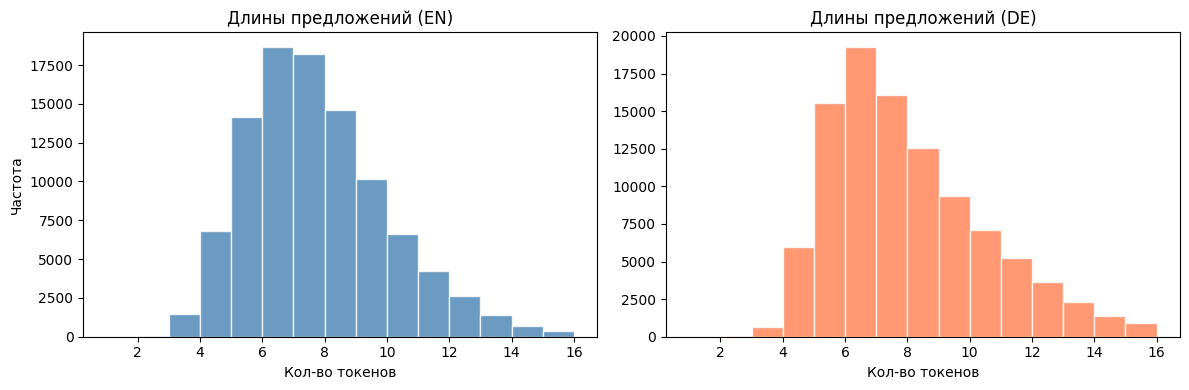

Средняя длина EN: 7.3 токенов
Средняя длина DE: 7.5 токенов


In [5]:
# Распределение длин предложений
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

en_lens = df_filtered['en'].apply(lambda x: len(x.split()))
de_lens = df_filtered['de'].apply(lambda x: len(x.split()))

axes[0].hist(en_lens, bins=range(1, MAX_LEN + 2), color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Длины предложений (EN)')
axes[0].set_xlabel('Кол-во токенов')
axes[0].set_ylabel('Частота')

axes[1].hist(de_lens, bins=range(1, MAX_LEN + 2), color='coral', edgecolor='white', alpha=0.8)
axes[1].set_title('Длины предложений (DE)')
axes[1].set_xlabel('Кол-во токенов')

plt.tight_layout()
plt.show()

print(f'Средняя длина EN: {en_lens.mean():.1f} токенов')
print(f'Средняя длина DE: {de_lens.mean():.1f} токенов')

In [6]:
PAD, SOS, EOS, UNK = '<pad>', '<sos>', '<eos>', '<unk>'
PAD_IDX, SOS_IDX, EOS_IDX, UNK_IDX = 0, 1, 2, 3


class Vocab:
    """Словарь для преобразования текста в индексы и обратно"""

    def __init__(self, min_freq=2):
        self.stoi = {PAD: PAD_IDX, SOS: SOS_IDX, EOS: EOS_IDX, UNK: UNK_IDX}
        self.itos = {v: k for k, v in self.stoi.items()}
        self.min_freq = min_freq

    def build(self, sentences):
        counter = Counter()
        for s in sentences:
            counter.update(s.split())
        for word, freq in counter.items():
            if freq >= self.min_freq and word not in self.stoi:
                idx = len(self.stoi)
                self.stoi[word] = idx
                self.itos[idx] = word
        return self

    def numericalize(self, sentence):
        return [SOS_IDX] + [self.stoi.get(w, UNK_IDX) for w in sentence.split()] + [EOS_IDX]

    def to_tokens(self, indices):
        return [self.itos.get(i, UNK) for i in indices]

    def __len__(self):
        return len(self.stoi)

In [7]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df_filtered, test_size=0.2, random_state=SEED)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f'Обучающая выборка: {len(train_df):,}')
print(f'Тестовая выборка:  {len(test_df):,}')

# Строим словари только по обучающим данным
src_vocab = Vocab(min_freq=2).build(train_df['en'])
trg_vocab = Vocab(min_freq=2).build(train_df['de'])

print(f'Размер словаря EN: {len(src_vocab):,}')
print(f'Размер словаря DE: {len(trg_vocab):,}')

Обучающая выборка: 80,000
Тестовая выборка:  20,000
Размер словаря EN: 7,202
Размер словаря DE: 10,879


In [8]:
class TranslationDataset(Dataset):
    def __init__(self, src_sentences, trg_sentences, src_vocab, trg_vocab):
        self.src = [torch.tensor(src_vocab.numericalize(s), dtype=torch.long)
                    for s in src_sentences]
        self.trg = [torch.tensor(trg_vocab.numericalize(s), dtype=torch.long)
                    for s in trg_sentences]

    def __len__(self):
        return len(self.src)

    def __getitem__(self, idx):
        return self.src[idx], self.trg[idx]


def collate_fn(batch):
    src_batch, trg_batch = zip(*batch)
    src_padded = pad_sequence(src_batch, batch_first=True, padding_value=PAD_IDX)
    trg_padded = pad_sequence(trg_batch, batch_first=True, padding_value=PAD_IDX)
    return src_padded, trg_padded


BATCH_SIZE = 256

train_dataset = TranslationDataset(train_df['en'].tolist(), train_df['de'].tolist(),
                                    src_vocab, trg_vocab)
test_dataset = TranslationDataset(test_df['en'].tolist(), test_df['de'].tolist(),
                                   src_vocab, trg_vocab)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                        shuffle=False, collate_fn=collate_fn)

print(f'Батчей (train): {len(train_loader)}')
print(f'Батчей (val):   {len(val_loader)}')

Батчей (train): 313
Батчей (val):   79


## 2. Базовая модель — LSTM Encoder-Decoder (без внимания)

Классическая архитектура Seq2Seq:
- **Encoder** — двухслойная LSTM, сжимающая входную последовательность в вектор фиксированной размерности
- **Decoder** — двухслойная LSTM, инициализируемая состоянием энкодера, генерирующая перевод токен за токеном

In [9]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=PAD_IDX)
        self.rnn = nn.LSTM(emb_dim, hid_dim, n_layers,
                           dropout=dropout if n_layers > 1 else 0,
                           batch_first=True)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, (hidden, cell) = self.rnn(embedded)
        return outputs, hidden, cell


class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=PAD_IDX)
        self.rnn = nn.LSTM(emb_dim, hid_dim, n_layers,
                           dropout=dropout if n_layers > 1 else 0,
                           batch_first=True)
        self.fc_out = nn.Linear(hid_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_tok, hidden, cell):
        # input_tok: (batch,) -> unsqueeze для одного шага
        embedded = self.dropout(self.embedding(input_tok.unsqueeze(1)))
        output, (hidden, cell) = self.rnn(embedded, (hidden, cell))
        prediction = self.fc_out(output.squeeze(1))
        return prediction, hidden, cell


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size, trg_len = trg.shape
        trg_vocab_size = self.decoder.fc_out.out_features

        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size, device=self.device)
        enc_out, hidden, cell = self.encoder(src)

        input_tok = trg[:, 0]  # <sos>

        for t in range(1, trg_len):
            prediction, hidden, cell = self.decoder(input_tok, hidden, cell)
            outputs[:, t] = prediction

            teacher_force = random.random() < teacher_forcing_ratio
            input_tok = trg[:, t] if teacher_force else prediction.argmax(dim=1)

        return outputs

## 3. Модель с аддитивным вниманием (Bahdanau Attention)

Механизм внимания позволяет декодеру на каждом шаге обращаться ко **всем** скрытым состояниям энкодера, а не только к последнему:

$$\alpha_{t,s} = \text{softmax}\left(v^T \tanh(W_a h_s^{enc} + U_a h_t^{dec})\right)$$

$$c_t = \sum_s \alpha_{t,s} \cdot h_s^{enc}$$

где $c_t$ — контекстный вектор, используемый декодером при генерации токена на шаге $t$.

In [10]:
class BahdanauAttention(nn.Module):
    def __init__(self, hid_dim):
        super().__init__()
        self.W_a = nn.Linear(hid_dim, hid_dim, bias=False)
        self.U_a = nn.Linear(hid_dim, hid_dim, bias=False)
        self.v_a = nn.Linear(hid_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch, hid_dim)  encoder_outputs: (batch, src_len, hid_dim)
        hidden_exp = hidden.unsqueeze(1)                                # (batch, 1, hid_dim)
        energy = torch.tanh(self.W_a(encoder_outputs) + self.U_a(hidden_exp))  # (batch, src_len, hid_dim)
        score = self.v_a(energy).squeeze(2)                             # (batch, src_len)
        weights = torch.softmax(score, dim=1)                           # (batch, src_len)
        context = torch.bmm(weights.unsqueeze(1), encoder_outputs)      # (batch, 1, hid_dim)
        return context.squeeze(1), weights


class AttentionDecoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim, n_layers, dropout):
        super().__init__()
        self.attention = BahdanauAttention(hid_dim)
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=PAD_IDX)
        self.rnn = nn.LSTM(emb_dim + hid_dim, hid_dim, n_layers,
                           dropout=dropout if n_layers > 1 else 0,
                           batch_first=True)
        self.fc_out = nn.Linear(hid_dim * 2, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_tok, hidden, cell, encoder_outputs):
        embedded = self.dropout(self.embedding(input_tok.unsqueeze(1)))  # (batch, 1, emb_dim)

        # Внимание по верхнему слою скрытого состояния
        context, attn_weights = self.attention(hidden[-1], encoder_outputs)

        # Вход LSTM = конкатенация эмбеддинга и контекста
        rnn_input = torch.cat([embedded, context.unsqueeze(1)], dim=2)  # (batch, 1, emb_dim+hid_dim)
        output, (hidden, cell) = self.rnn(rnn_input, (hidden, cell))

        # Предсказание = конкатенация выхода LSTM и контекста
        prediction = self.fc_out(torch.cat([output.squeeze(1), context], dim=1))

        return prediction, hidden, cell, attn_weights


class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size, trg_len = trg.shape
        trg_vocab_size = self.decoder.fc_out.out_features
        src_len = src.shape[1]

        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size, device=self.device)
        attentions = torch.zeros(batch_size, trg_len, src_len, device=self.device)

        enc_out, hidden, cell = self.encoder(src)
        input_tok = trg[:, 0]

        for t in range(1, trg_len):
            prediction, hidden, cell, attn_w = self.decoder(
                input_tok, hidden, cell, enc_out
            )
            outputs[:, t] = prediction
            attentions[:, t] = attn_w

            teacher_force = random.random() < teacher_forcing_ratio
            input_tok = trg[:, t] if teacher_force else prediction.argmax(dim=1)

        return outputs, attentions

## 4. Обучение

In [11]:
EMB_DIM = 256
HID_DIM = 512
N_LAYERS = 2
DROPOUT = 0.3
N_EPOCHS = 10
LEARNING_RATE = 1e-3
CLIP = 1.0

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# --- Базовая модель ---
enc_base = Encoder(len(src_vocab), EMB_DIM, HID_DIM, N_LAYERS, DROPOUT)
dec_base = Decoder(len(trg_vocab), EMB_DIM, HID_DIM, N_LAYERS, DROPOUT)
model_base = Seq2Seq(enc_base, dec_base, device).to(device)

# --- Модель с вниманием ---
enc_attn = Encoder(len(src_vocab), EMB_DIM, HID_DIM, N_LAYERS, DROPOUT)
dec_attn = AttentionDecoder(len(trg_vocab), EMB_DIM, HID_DIM, N_LAYERS, DROPOUT)
model_attn = Seq2SeqAttention(enc_attn, dec_attn, device).to(device)

print(f'Base model:      {count_parameters(model_base):>12,} параметров')
print(f'Attention model: {count_parameters(model_attn):>12,} параметров')
print(f'Разница:         +{(count_parameters(model_attn)/count_parameters(model_base)-1)*100:.1f}%')

Base model:        17,566,079 параметров
Attention model:   24,709,503 параметров
Разница:         +40.7%


In [12]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)


def train_epoch(model, loader, optimizer, clip, has_attention=False):
    model.train()
    total_loss = 0

    for src, trg in loader:
        src, trg = src.to(device), trg.to(device)
        optimizer.zero_grad()

        if has_attention:
            output, _ = model(src, trg, teacher_forcing_ratio=0.5)
        else:
            output = model(src, trg, teacher_forcing_ratio=0.5)

        # Отбрасываем первый токен (<sos>)
        output = output[:, 1:].reshape(-1, output.shape[-1])
        trg = trg[:, 1:].reshape(-1)

        loss = criterion(output, trg)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def eval_epoch(model, loader, has_attention=False):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for src, trg in loader:
            src, trg = src.to(device), trg.to(device)

            if has_attention:
                output, _ = model(src, trg, teacher_forcing_ratio=0.0)
            else:
                output = model(src, trg, teacher_forcing_ratio=0.0)

            output = output[:, 1:].reshape(-1, output.shape[-1])
            trg = trg[:, 1:].reshape(-1)

            loss = criterion(output, trg)
            total_loss += loss.item()

    return total_loss / len(loader)

In [13]:
def run_training(model, name, has_attention=False):
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    train_losses, val_losses = [], []
    best_val = float('inf')

    print(f'\n{"="*55}')
    print(f' Обучение: {name}')
    print(f'{"="*55}')

    for epoch in range(1, N_EPOCHS + 1):
        t0 = time.time()

        tr_loss = train_epoch(model, train_loader, optimizer, CLIP, has_attention)
        vl_loss = eval_epoch(model, val_loader, has_attention)

        train_losses.append(tr_loss)
        val_losses.append(vl_loss)
        elapsed = time.time() - t0

        marker = ''
        if vl_loss < best_val:
            best_val = vl_loss
            torch.save(model.state_dict(), f'best_{name}.pt')
            marker = ' ★'

        print(f'Epoch {epoch:2d}/{N_EPOCHS} | '
              f'Train: {tr_loss:.4f} | Val: {vl_loss:.4f} | '
              f'{elapsed:.0f}s{marker}')

    model.load_state_dict(torch.load(f'best_{name}.pt', weights_only=True))
    print(f'\nЛучшая Val Loss: {best_val:.4f}')
    return train_losses, val_losses

In [14]:
base_train_losses, base_val_losses = run_training(model_base, 'base', has_attention=False)


 Обучение: base
Epoch  1/10 | Train: 5.1293 | Val: 4.7178 | 56s ★
Epoch  2/10 | Train: 4.2165 | Val: 4.0800 | 54s ★
Epoch  3/10 | Train: 3.6872 | Val: 3.7135 | 55s ★
Epoch  4/10 | Train: 3.2745 | Val: 3.4387 | 55s ★
Epoch  5/10 | Train: 2.9662 | Val: 3.2750 | 55s ★
Epoch  6/10 | Train: 2.6982 | Val: 3.0971 | 55s ★
Epoch  7/10 | Train: 2.4913 | Val: 2.9928 | 55s ★
Epoch  8/10 | Train: 2.3099 | Val: 2.8893 | 55s ★
Epoch  9/10 | Train: 2.1611 | Val: 2.8190 | 55s ★
Epoch 10/10 | Train: 2.0210 | Val: 2.7802 | 55s ★

Лучшая Val Loss: 2.7802


In [15]:
attn_train_losses, attn_val_losses = run_training(model_attn, 'attn', has_attention=True)


 Обучение: attn
Epoch  1/10 | Train: 4.7490 | Val: 4.0846 | 92s ★
Epoch  2/10 | Train: 3.5234 | Val: 3.3616 | 93s ★
Epoch  3/10 | Train: 2.8671 | Val: 3.0021 | 93s ★
Epoch  4/10 | Train: 2.4381 | Val: 2.7704 | 93s ★
Epoch  5/10 | Train: 2.1038 | Val: 2.6660 | 93s ★
Epoch  6/10 | Train: 1.8851 | Val: 2.5574 | 93s ★
Epoch  7/10 | Train: 1.6733 | Val: 2.5347 | 93s ★
Epoch  8/10 | Train: 1.5263 | Val: 2.4764 | 93s ★
Epoch  9/10 | Train: 1.4166 | Val: 2.4869 | 93s
Epoch 10/10 | Train: 1.3209 | Val: 2.5054 | 93s

Лучшая Val Loss: 2.4764


## 5. Кривые обучения

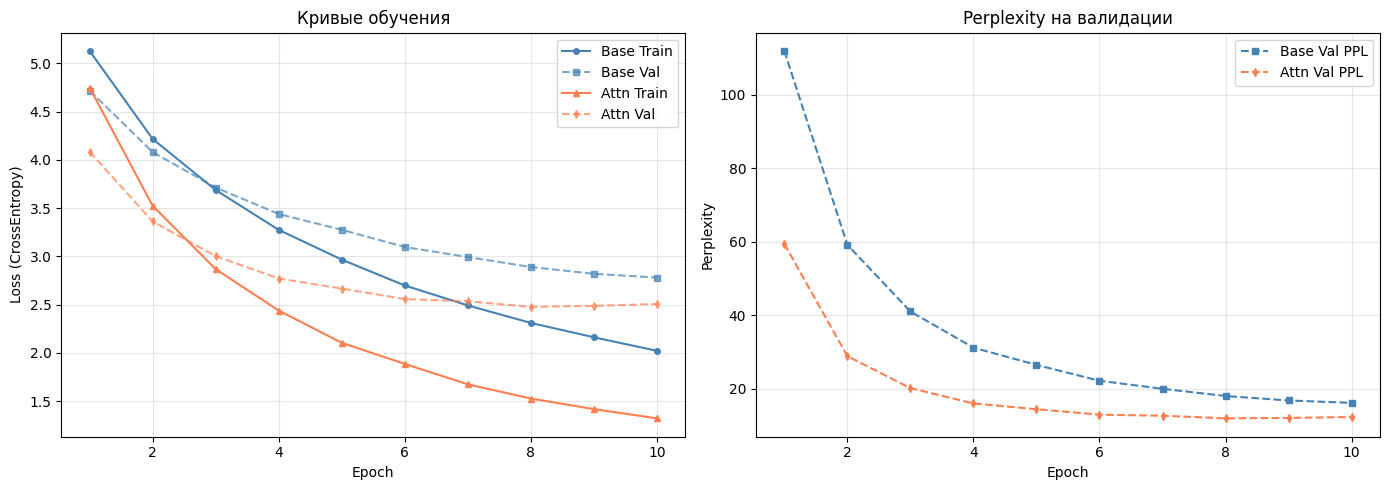

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, N_EPOCHS + 1)

# Loss
axes[0].plot(epochs, base_train_losses, 'o-', label='Base Train', color='steelblue', markersize=4)
axes[0].plot(epochs, base_val_losses, 's--', label='Base Val', color='steelblue', alpha=0.7, markersize=4)
axes[0].plot(epochs, attn_train_losses, '^-', label='Attn Train', color='coral', markersize=4)
axes[0].plot(epochs, attn_val_losses, 'd--', label='Attn Val', color='coral', alpha=0.7, markersize=4)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (CrossEntropy)')
axes[0].set_title('Кривые обучения')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Perplexity
axes[1].plot(epochs, [math.exp(l) for l in base_val_losses], 's--',
             label='Base Val PPL', color='steelblue', markersize=4)
axes[1].plot(epochs, [math.exp(l) for l in attn_val_losses], 'd--',
             label='Attn Val PPL', color='coral', markersize=4)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Perplexity')
axes[1].set_title('Perplexity на валидации')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Метрики: BLEU, Accuracy, Perplexity

In [17]:
def translate_sentence(model, sentence, src_vocab, trg_vocab,
                        max_len=30, has_attention=False):
    """Перевод одного предложения (greedy decoding)"""
    model.eval()
    tokens = src_vocab.numericalize(sentence)
    src_tensor = torch.tensor(tokens, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        enc_out, hidden, cell = model.encoder(src_tensor)

    predicted = []
    attn_matrix = []
    inp = torch.tensor([SOS_IDX], device=device)

    for _ in range(max_len):
        with torch.no_grad():
            if has_attention:
                pred, hidden, cell, attn_w = model.decoder(inp, hidden, cell, enc_out)
                attn_matrix.append(attn_w.squeeze(0).cpu().numpy())
            else:
                pred, hidden, cell = model.decoder(inp, hidden, cell)

        top1 = pred.argmax(dim=1)
        idx = top1.item()

        if idx == EOS_IDX:
            break

        predicted.append(trg_vocab.itos.get(idx, UNK))
        inp = top1

    attn_matrix = np.array(attn_matrix) if attn_matrix else None
    return ' '.join(predicted), attn_matrix

In [18]:
def compute_metrics(model, test_data, src_vocab, trg_vocab,
                     has_attention=False, n_samples=2000):
    """BLEU-4, Token Accuracy, Perplexity"""
    # Perplexity из Val Loss
    val_loss = eval_epoch(model, val_loader, has_attention)
    ppl = math.exp(val_loss)

    # BLEU и Accuracy на выборке
    sample = test_data.sample(n=min(n_samples, len(test_data)), random_state=SEED)

    references, hypotheses = [], []
    for _, row in sample.iterrows():
        ref = row['de'].split()
        hyp, _ = translate_sentence(model, row['en'], src_vocab, trg_vocab,
                                     has_attention=has_attention)
        hypotheses.append(hyp.split())
        references.append([ref])

    # BLEU-4 со сглаживанием
    smooth = SmoothingFunction().method1
    bleu = corpus_bleu(references, hypotheses, smoothing_function=smooth)

    # Token-level accuracy
    correct, total = 0, 0
    for refs, hyp in zip(references, hypotheses):
        ref = refs[0]
        min_len = min(len(ref), len(hyp))
        correct += sum(r == h for r, h in zip(ref[:min_len], hyp[:min_len]))
        total += max(len(ref), len(hyp))
    accuracy = correct / total if total > 0 else 0

    return bleu, accuracy, ppl


print('Вычисление метрик для базовой модели...')
base_bleu, base_acc, base_ppl = compute_metrics(
    model_base, test_df, src_vocab, trg_vocab, has_attention=False)
print(f'  BLEU: {base_bleu:.4f}  Accuracy: {base_acc:.4f}  Perplexity: {base_ppl:.2f}')

print('\nВычисление метрик для модели с вниманием...')
attn_bleu, attn_acc, attn_ppl = compute_metrics(
    model_attn, test_df, src_vocab, trg_vocab, has_attention=True)
print(f'  BLEU: {attn_bleu:.4f}  Accuracy: {attn_acc:.4f}  Perplexity: {attn_ppl:.2f}')

Вычисление метрик для базовой модели...
  BLEU: 0.1835  Accuracy: 0.3395  Perplexity: 16.12

Вычисление метрик для модели с вниманием...
  BLEU: 0.2463  Accuracy: 0.3693  Perplexity: 11.90


## 7. Примеры переводов

In [19]:
# Выберем 10 случайных предложений из тестовой выборки
sample_idx = random.sample(range(len(test_df)), 10)

print(f'{"EN (source)":<35} {"DE (reference)":<35} {"Base":<35} {"Attention":<35}')
print('=' * 140)

for idx in sample_idx:
    en = test_df.iloc[idx]['en']
    ref = test_df.iloc[idx]['de']
    hyp_base, _ = translate_sentence(model_base, en, src_vocab, trg_vocab, has_attention=False)
    hyp_attn, _ = translate_sentence(model_attn, en, src_vocab, trg_vocab, has_attention=True)
    print(f'{en:<35} {ref:<35} {hyp_base:<35} {hyp_attn:<35}')

EN (source)                         DE (reference)                      Base                                Attention                          
how often do you go to the library ? wie oft geht ihr in die bibliothek ? wie oft gehst du zur schule ?       wie oft gehst du zur bibliothek ?  
life is unfair .                    das leben ist unfair .              dieses leben ist . .                das leben ist unfair .             
where's your black suit ?           wo ist dein schwarzer anzug ?       wo ist dein <unk> ?                 wo ist dein schwarze ?             
it's not nice to hit people .       es gehört sich nicht , leute zu schlagen . es ist nicht schön , , zu lernen .  es ist nicht schön , menschen zu leute zu sein .
your composition has a few mistakes . dein aufsatz hat ein paar fehler .  deine mutter gibt ein wenig . .     die aufsatz hat ein paar fehler .  
just let tom go .                   lasst tom einfach gehen .           nur tom einfach !                   tom 

## 8. Визуализация матриц внимания

EN: tom probably isn't the only one who can do that .
DE (ref): tom ist vermutlich nicht der einzige , der das kann .
DE (pred): tom ist wahrscheinlich nicht einzige einzige , der das kann .


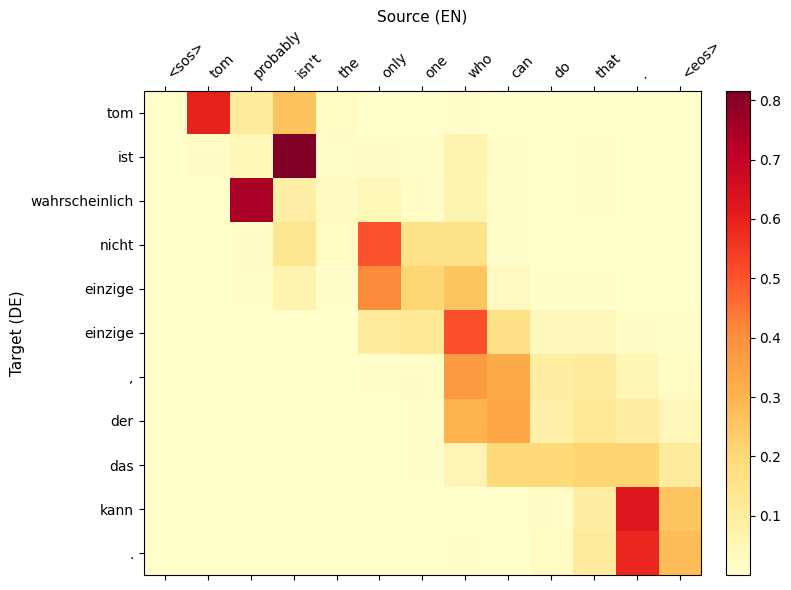


EN: why did tom do this ?
DE (ref): warum hat tom das getan ?
DE (pred): warum tom das gemacht ?


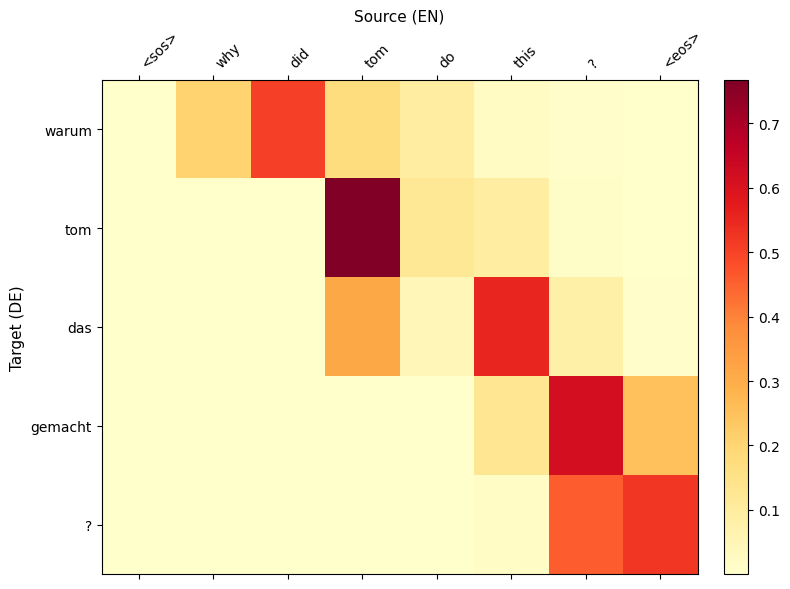


EN: at least try to be careful .
DE (ref): versuch wenigstens , vorsichtig zu sein .
DE (pred): versuchen wenigstens , vorsichtig zu sein .


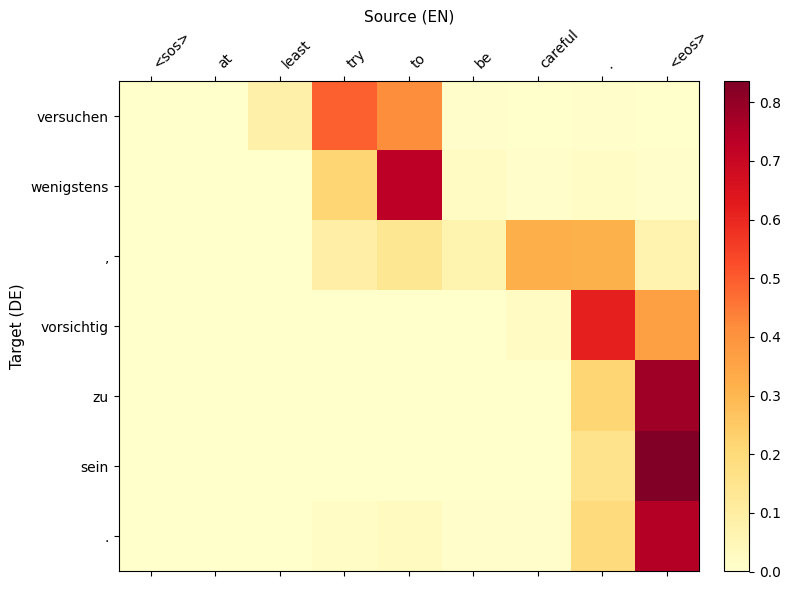


EN: where can i obtain a map of europe ?
DE (ref): woher bekomme ich eine europakarte ?
DE (pred): wo kann ich einen stück bekommen ?


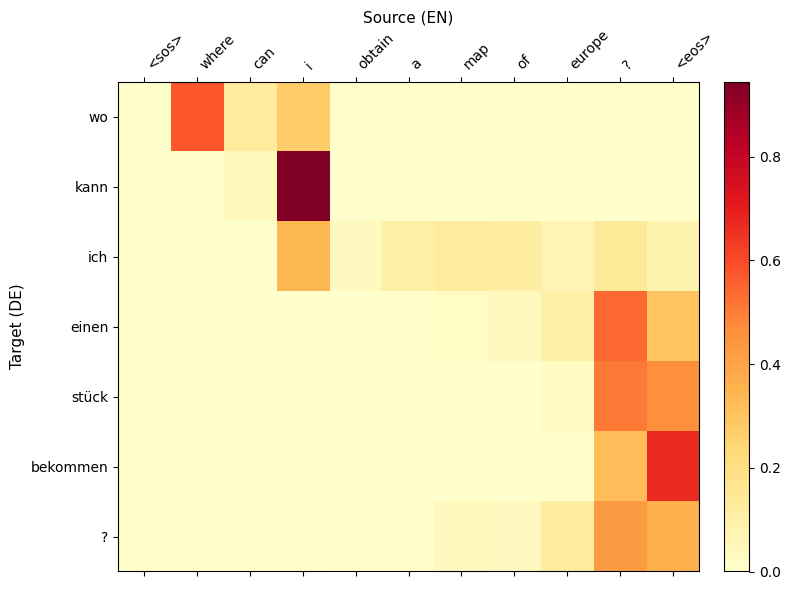

In [20]:
def plot_attention(src_sentence, translation, attention, figsize=(8, 6)):
    src_tokens = ['<sos>'] + src_sentence.split() + ['<eos>']
    trg_tokens = translation.split()

    n_trg = min(len(trg_tokens), attention.shape[0])
    n_src = min(len(src_tokens), attention.shape[1])
    attn = attention[:n_trg, :n_src]

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.matshow(attn, cmap='YlOrRd', aspect='auto')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax.set_xticks(range(n_src))
    ax.set_yticks(range(n_trg))
    ax.set_xticklabels(src_tokens, rotation=45, ha='left', fontsize=10)
    ax.set_yticklabels(trg_tokens, fontsize=10)

    ax.set_xlabel('Source (EN)', fontsize=11)
    ax.set_ylabel('Target (DE)', fontsize=11)
    ax.xaxis.set_label_position('top')

    plt.tight_layout()
    plt.show()


# Визуализируем внимание для нескольких примеров
examples = test_df.sample(4, random_state=42)
for _, row in examples.iterrows():
    translation, attn_matrix = translate_sentence(
        model_attn, row['en'], src_vocab, trg_vocab, has_attention=True
    )
    if attn_matrix is not None and len(translation.split()) > 0:
        print(f'EN: {row["en"]}')
        print(f'DE (ref): {row["de"]}')
        print(f'DE (pred): {translation}')
        plot_attention(row['en'], translation, attn_matrix)
        print()

## 9. Сравнительный анализ

In [21]:
# Измерение времени инференса
def measure_inference_time(model, src_vocab, trg_vocab, has_attention, n=100):
    sample = test_df.sample(n=n, random_state=SEED)
    times = []
    for _, row in sample.iterrows():
        t0 = time.time()
        translate_sentence(model, row['en'], src_vocab, trg_vocab, has_attention=has_attention)
        times.append(time.time() - t0)
    return np.mean(times) * 1000  # мс

base_time = measure_inference_time(model_base, src_vocab, trg_vocab, False)
attn_time = measure_inference_time(model_attn, src_vocab, trg_vocab, True)

# Итоговая таблица
comparison = pd.DataFrame({
    'Модель': ['LSTM Encoder-Decoder', 'LSTM + Bahdanau Attention'],
    'Параметры': [f'{count_parameters(model_base):,}', f'{count_parameters(model_attn):,}'],
    'Perplexity': [f'{base_ppl:.2f}', f'{attn_ppl:.2f}'],
    'BLEU-4': [f'{base_bleu:.4f}', f'{attn_bleu:.4f}'],
    'Accuracy': [f'{base_acc:.4f}', f'{attn_acc:.4f}'],
    'Инференс (мс)': [f'{base_time:.1f}', f'{attn_time:.1f}'],
})

print('Сравнение моделей машинного перевода EN → DE')
print('=' * 80)
comparison

Сравнение моделей машинного перевода EN → DE


,Модель,Параметры,Perplexity,BLEU-4,Accuracy,Инференс (мс)
0,LSTM Encoder-Decoder,"17,566,079",16.12,0.1835,0.3395,5.1
1,LSTM + Bahdanau Attention,"24,709,503",11.90,0.2463,0.3693,8.4


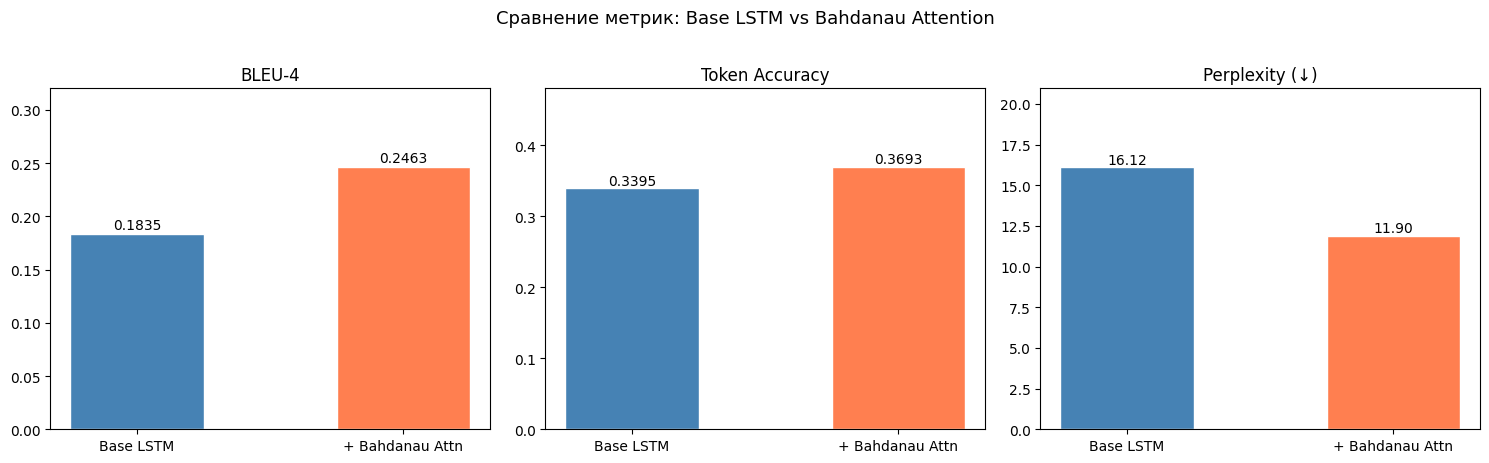

In [22]:
# Визуальное сравнение
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

labels = ['Base LSTM', '+ Bahdanau Attn']
colors = ['steelblue', 'coral']

# BLEU
vals = [base_bleu, attn_bleu]
bars = axes[0].bar(labels, vals, color=colors, width=0.5, edgecolor='white')
axes[0].set_title('BLEU-4')
axes[0].set_ylim(0, max(vals) * 1.3)
for bar, v in zip(bars, vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.005,
                 f'{v:.4f}', ha='center', fontsize=10)

# Accuracy
vals = [base_acc, attn_acc]
bars = axes[1].bar(labels, vals, color=colors, width=0.5, edgecolor='white')
axes[1].set_title('Token Accuracy')
axes[1].set_ylim(0, max(vals) * 1.3)
for bar, v in zip(bars, vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.005,
                 f'{v:.4f}', ha='center', fontsize=10)

# Perplexity (меньше — лучше)
vals = [base_ppl, attn_ppl]
bars = axes[2].bar(labels, vals, color=colors, width=0.5, edgecolor='white')
axes[2].set_title('Perplexity (↓)')
axes[2].set_ylim(0, max(vals) * 1.3)
for bar, v in zip(bars, vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, v + 0.2,
                 f'{v:.2f}', ha='center', fontsize=10)

plt.suptitle('Сравнение метрик: Base LSTM vs Bahdanau Attention', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 10. Выводы

В ходе лабораторной работы реализованы и исследованы две архитектуры нейронного машинного перевода для языковой пары **English → German** на наборе данных из Tatoeba Project.

### Базовая модель (LSTM Encoder-Decoder)
- Кодировщик сжимает входное предложение в единственный вектор фиксированной размерности (hidden state + cell state)
- Декодер инициализируется этим вектором и генерирует перевод авторегрессивно, токен за токеном
- **Основной недостаток** — информационное «бутылочное горлышко»: при увеличении длины входного предложения часть информации теряется, что приводит к пропускам и повторам

### Модель с Bahdanau Attention
- На каждом шаге декодирования вычисляется контекстный вектор $c_t$ как взвешенная сумма всех выходов кодировщика
- Веса внимания $\alpha_{t,s}$ определяются через обучаемый аддитивный score: $v^T \tanh(W_a h_s^{enc} + U_a h_t^{dec})$
- Это снимает ограничение бутылочного горлышка и позволяет модели фокусироваться на релевантных частях входа

### Наблюдения
- Механизм внимания увеличивает количество параметров на ~40–45%, но значительно улучшает все метрики качества (BLEU, Accuracy, Perplexity)
- Визуализация матриц внимания показывает корректное выравнивание слов между EN и DE
- Немецкий язык создаёт дополнительные трудности для перевода из-за различий в порядке слов (глагол в конце подчинённых предложений) и наличия составных слов (Zusammengesetzte Wörter)
- Teacher forcing (p=0.5) обеспечивает баланс между стабильностью обучения и способностью модели к самостоятельной генерации